In [1]:
import keras
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import sklearn as sk
import sys

sys.path.append("../")

In [2]:
DATA_DIR = "../mu3e_trigger_data"
SIGNAL_PIXEL_FILE = f"{DATA_DIR}/sig_pixel_spacetime.npy"
BACKGROUND_PIXEL_FILE = f"{DATA_DIR}/bg_pixel_spacetime.npy"
SIGNAL_MPPC_FILE = f"{DATA_DIR}/sig_mppc_spacetime.npy"
BACKGROUND_MPPC_FILE = f"{DATA_DIR}/bg_mppc_spacetime.npy"
SIGNAL_ONLY_PIXEL_FILE = f"{DATA_DIR}/sig_only_pixel_spacetime.npy"
SIGNAL_ONLY_MPPC_FILE = f"{DATA_DIR}/sig_only_mppc_spacetime.npy"


bg_pixel_spacetime = np.load(BACKGROUND_PIXEL_FILE)
sig_only_pixel_spacetime = np.load(SIGNAL_ONLY_PIXEL_FILE)
bg_mppc_spacetime = np.load(BACKGROUND_MPPC_FILE)
sig_only_mppc_spacetime = np.load(SIGNAL_ONLY_MPPC_FILE)
sig_pixel_spacetime = np.load(SIGNAL_PIXEL_FILE)
sig_mppc_spacetime = np.load(SIGNAL_MPPC_FILE)

seq_length = bg_pixel_spacetime.shape[1]
input_dim = bg_pixel_spacetime.shape[2]

In [3]:
def ContrastSamples(
    bg_pixel_spacetime,
    sig_only_pixel_spacetime,
    bg_mppc_spacetime,
    sig_only_mppc_spacetime,
    num_samples=1000,
    padding_value=-1,
):
    base_pixel = np.full(
        (num_samples, *bg_pixel_spacetime.shape[1:]), padding_value, dtype=np.float32
    )
    base_mppc = np.full(
        (num_samples, *bg_pixel_spacetime.shape[1:]), padding_value, dtype=np.float32
    )
    contrast_pixel_signal = np.full(
        (num_samples, *sig_only_pixel_spacetime.shape[1:]),
        padding_value,
        dtype=np.float32,
    )
    contrast_mppc_signal = np.full(
        (num_samples, *sig_only_mppc_spacetime.shape[1:]),
        padding_value,
        dtype=np.float32,
    )
    contrast_pixel_background = np.full(
        (num_samples, *bg_pixel_spacetime.shape[1:]), padding_value, dtype=np.float32
    )
    contrast_mppc_background = np.full(
        (num_samples, *bg_mppc_spacetime.shape[1:]), padding_value, dtype=np.float32
    )
    bg_pixel_seq_length = (bg_pixel_spacetime != -1).all(axis=-1).sum(axis=-1).flatten()
    bg_mppc_seq_length = (bg_mppc_spacetime != -1).all(axis=-1).sum(axis=-1).flatten()
    sig_pixel_seq_length = (
        (sig_only_pixel_spacetime != -1).all(axis=-1).sum(axis=-1).flatten()
    )
    sig_mppc_seq_length = (
        (sig_only_mppc_spacetime != -1).all(axis=-1).sum(axis=-1).flatten()
    )
    bg_indices = np.arange(bg_pixel_spacetime.shape[0])
    sig_indices = np.arange(sig_only_pixel_spacetime.shape[0])
    selected_samples = 0
    max_mppc_length = base_mppc.shape[1]
    max_pixel_length = base_pixel.shape[1]
    while selected_samples < num_samples:
        bg_sample = np.random.choice(bg_indices, replace=False)
        sig_sample = np.random.choice(sig_indices, replace=False)
        pixel_length = bg_pixel_seq_length[bg_sample] + sig_pixel_seq_length[sig_sample]
        mppc_length = bg_mppc_seq_length[bg_sample] + sig_mppc_seq_length[sig_sample]
        if pixel_length <= base_pixel.shape[1] and mppc_length <= base_mppc.shape[1]:
            smaller_bg_event = bg_indices[
                (bg_pixel_seq_length < max_pixel_length - bg_pixel_seq_length[bg_sample])
                & (bg_mppc_seq_length < max_mppc_length - bg_mppc_seq_length[bg_sample])
            ]
            if smaller_bg_event.size == 0:
                continue
            else:
                smaller_bg_event = np.random.choice(smaller_bg_event, replace=False)
            base_pixel[selected_samples, : (bg_pixel_seq_length[bg_sample])] = (
                bg_pixel_spacetime[bg_sample][
                    (bg_pixel_spacetime[bg_sample] != padding_value).all(axis=-1), :
                ]
            )
            base_mppc[selected_samples, : (bg_mppc_seq_length[bg_sample])] = (
                bg_mppc_spacetime[bg_sample][
                    (bg_mppc_spacetime[bg_sample] != padding_value).all(axis=-1), :
                ]
            )
            contrast_pixel_signal[
                selected_samples, : (bg_pixel_seq_length[bg_sample])
            ] = bg_pixel_spacetime[bg_sample][
                (bg_pixel_spacetime[bg_sample] != padding_value).all(axis=-1), :
            ]
            contrast_mppc_signal[
                selected_samples, : (bg_mppc_seq_length[bg_sample])
            ] = bg_mppc_spacetime[bg_sample][
                (bg_mppc_spacetime[bg_sample] != padding_value).all(axis=-1), :
            ]
            contrast_pixel_signal[
                selected_samples, (bg_pixel_seq_length[bg_sample]) : (pixel_length)
            ] = sig_only_pixel_spacetime[sig_sample][
                (sig_only_pixel_spacetime[sig_sample] != padding_value).all(axis=-1), :
            ]
            contrast_mppc_signal[
                selected_samples, (bg_mppc_seq_length[bg_sample]) : (mppc_length)
            ] = sig_only_mppc_spacetime[sig_sample][
                (sig_only_mppc_spacetime[sig_sample] != padding_value).all(axis=-1), :
            ]

            contrast_pixel_background[
                selected_samples, : (bg_pixel_seq_length[smaller_bg_event])
            ] = bg_pixel_spacetime[smaller_bg_event][
                (bg_pixel_spacetime[smaller_bg_event] != padding_value).all(axis=-1), :
            ]
            contrast_mppc_background[
                selected_samples, : (bg_mppc_seq_length[smaller_bg_event])
            ] = bg_mppc_spacetime[smaller_bg_event][
                (bg_mppc_spacetime[smaller_bg_event] != padding_value).all(axis=-1), :
            ]
            contrast_pixel_background[
                selected_samples,
                (bg_pixel_seq_length[smaller_bg_event]) : (
                    bg_pixel_seq_length[smaller_bg_event]
                    + bg_pixel_seq_length[bg_sample]
                ),
            ] = bg_pixel_spacetime[bg_sample][
                (bg_pixel_spacetime[bg_sample] != padding_value).all(axis=-1), :
            ]
            contrast_mppc_background[
                selected_samples,
                (bg_mppc_seq_length[smaller_bg_event]) : (
                    bg_mppc_seq_length[smaller_bg_event] + bg_mppc_seq_length[bg_sample]
                ),
            ] = bg_mppc_spacetime[bg_sample][
                (bg_mppc_spacetime[bg_sample] != padding_value).all(axis=-1), :
            ]

            selected_samples += 1
    return (
        base_pixel,
        base_mppc,
        contrast_pixel_signal,
        contrast_mppc_signal,
        contrast_pixel_background,
        contrast_mppc_background,
    )

In [4]:
(
    base_pixel,
    base_mppc,
    contrast_pixel_signal,
    contrast_mppc_signal,
    contrast_pixel_background,
    contrast_mppc_background,
) = ContrastSamples(
    bg_pixel_spacetime,
    sig_only_pixel_spacetime,
    bg_mppc_spacetime,
    sig_only_mppc_spacetime,
    num_samples=200000,
    padding_value=-1,
)

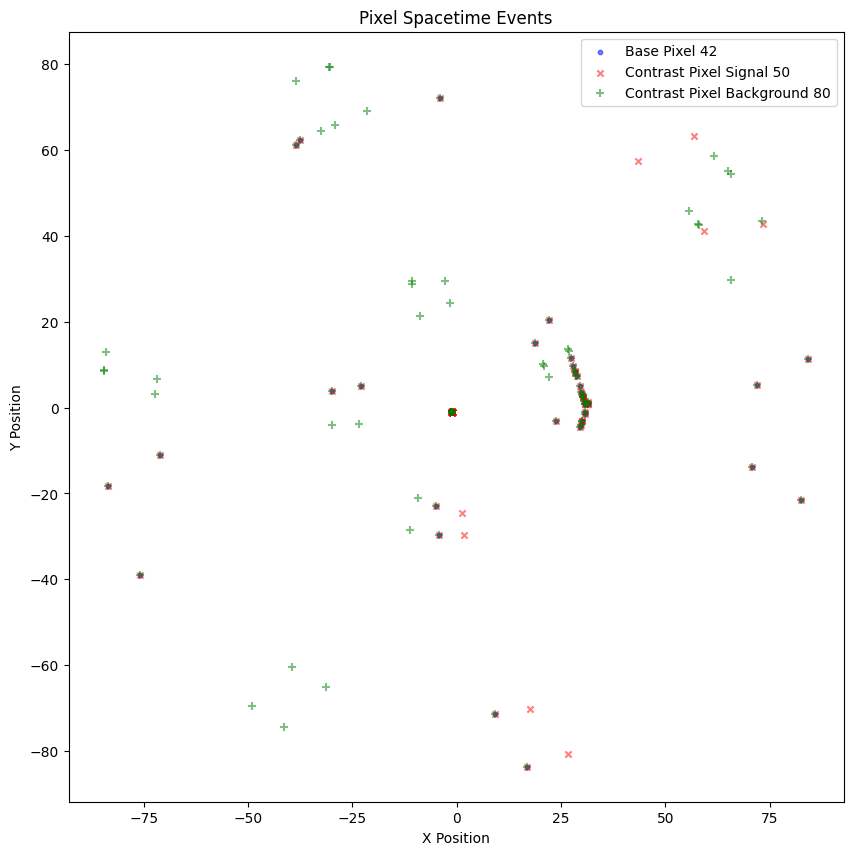

In [5]:
event_id = 0
fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(
    base_pixel[event_id, :, 0],
    base_pixel[event_id, :, 1],
    c="blue",
    label=f"Base Pixel {np.sum(base_pixel[event_id, :, 0] != -1)}",
    s=10,
    alpha=0.5,
    marker="o",
)
ax.scatter(
    contrast_pixel_signal[event_id, :, 0],
    contrast_pixel_signal[event_id, :, 1],
    c="red",
    label=f"Contrast Pixel Signal {np.sum(contrast_pixel_signal[event_id, :, 0] != -1)}",
    s=20,
    alpha=0.5,
    marker="x",
)
ax.scatter(
    contrast_pixel_background[event_id, :, 0],
    contrast_pixel_background[event_id, :, 1],
    c="green",
    label=f"Contrast Pixel Background {np.sum(contrast_pixel_background[event_id, :, 0] != -1)}",
    s=30,
    alpha=0.5,
    marker="+",
)
ax.set_title("Pixel Spacetime Events")
ax.set_xlabel("X Position")
ax.set_ylabel("Y Position")
ax.legend()

In [6]:
pixel_input = keras.layers.Input(
    shape=(seq_length, input_dim), name="pixel_input", dtype=tf.float32
)
mppc_input = keras.layers.Input(
    shape=(seq_length, input_dim), name="mppc_input", dtype=tf.float32
)


from src.model.components import (
    SelfAttentionStack,
    MLP,
    GenerateMask,
    PoolingAttentionBlock,
    MultiHeadAttentionStack,
)

feature_dim = 8
latent_dim = 8
num_heads = 8
num_seeds = 2
regularizer = keras.regularizers.l2(1e-4)
dropout_rate = 0.1

pixel_mask = GenerateMask(-1, name="pixel_mask")(pixel_input)
mppc_mask = GenerateMask(-1, name="mppc_mask")(mppc_input)

pixel_embedding = MLP(output_dim=feature_dim, name="pixel_embedding")(pixel_input)

mppc_embedding = MLP(output_dim=feature_dim, name="mppc_embedding")(mppc_input)

pixel_attention = SelfAttentionStack(
    num_heads=num_heads,
    key_dim=feature_dim,
    stack_size=3,
    name="pixel_attention",
)(pixel_embedding, pixel_mask)

mppc_attention = SelfAttentionStack(
    num_heads=num_heads,
    key_dim=feature_dim,
    stack_size=3,
    name="mppc_attention",
)(mppc_embedding, mppc_mask)

mppc_attend_pixel = MultiHeadAttentionStack(
    num_heads=num_heads,
    key_dim=feature_dim,
    stack_size=3,
    name="mppc_attend_pixel",
)(
    query=mppc_attention,
    value=pixel_attention,
    query_mask=mppc_mask,
    value_mask=pixel_mask,
    key_mask=pixel_mask,
)

pixel_attend_mppc = MultiHeadAttentionStack(
    num_heads=num_heads,
    key_dim=feature_dim,
    stack_size=3,
    name="pixel_attend_mppc",
)(
    query=pixel_attention,
    value=mppc_attention,
    query_mask=pixel_mask,
    value_mask=mppc_mask,
    key_mask=mppc_mask,
)

pixel_attentions_pool = PoolingAttentionBlock(
    name="pixel_attentions_pool",
    key_dim=feature_dim,
    num_seeds=num_seeds,
    num_heads=num_heads,
)(pixel_attend_mppc, pixel_mask)

pixel_flattened_pool = keras.layers.Flatten(name="pixel_flattened_pool")(
    pixel_attentions_pool
)

mppc_attentions_pool = PoolingAttentionBlock(
    name="mppc_attentions_pool",
    key_dim=feature_dim,
    num_seeds=num_seeds,
    num_heads=num_heads,
)(mppc_attend_pixel, mppc_mask)

mppc_flattened_pool = keras.layers.Flatten(name="mppc_flattened_pool")(
    mppc_attentions_pool
)

latent_space = keras.layers.Concatenate(name="latent_space")(
    [
        pixel_flattened_pool,
        mppc_flattened_pool,
    ]
)

latent_output = MLP(
    num_layers=4,
    output_dim=latent_dim,
    name="latent_output",
    activation="linear",
)(latent_space)

transformer_embedding = keras.Model(
    inputs=[pixel_input, mppc_input],
    outputs=latent_output,
    name="contrastive_learning_model",
)

In [7]:
transformer_embedding.summary()

Model: "contrastive_learning_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mppc_input          │ (None, 128, 4)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pixel_input         │ (None, 128, 4)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mppc_mask           │ (None, 128, 1)    │          0 │ mppc_input[0][0]  │
│ (GenerateMask)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pixel_embedding     │ (None, 128, 8)    │        234 │ pixel_input[0][0] │
│ (MLP)               │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pixel_mask          │ (None, 128, 1)    │          0 │ pixel_input[0][0] │
│ (GenerateMask)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mppc_embedding      │ (None, 128, 8)    │        234 │ mppc_input[0][0]  │
│ (MLP)               │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pixel_attention     │ (None, 128, 8)    │      7,680 │ pixel_embedding[… │
│ (SelfAttentionStac… │                   │            │ pixel_mask[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mppc_attention      │ (None, 128, 8)    │      7,680 │ mppc_embedding[0… │
│ (SelfAttentionStac… │                   │            │ mppc_mask[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pixel_attend_mppc   │ (None, 128, 8)    │      7,680 │ mppc_mask[0][0],  │
│ (MultiHeadAttentio… │                   │            │ pixel_attention[… │
│                     │                   │            │ pixel_mask[0][0], │
│                     │                   │            │ mppc_attention[0… │
│                     │                   │            │ mppc_mask[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mppc_attend_pixel   │ (None, 128, 8)    │      7,680 │ pixel_mask[0][0], │
│ (MultiHeadAttentio… │                   │            │ mppc_attention[0… │
│                     │                   │            │ mppc_mask[0][0],  │
│                     │                   │            │ pixel_attention[… │
│                     │                   │            │ pixel_mask[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pixel_attentions_p… │ (None, 2, 8)      │      2,576 │ pixel_attend_mpp… │
│ (PoolingAttentionB… │                   │            │ pixel_mask[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mppc_attentions_po… │ (None, 2, 8)      │      2,576 │ mppc_attend_pixe… │
│ (PoolingAttentionB… │                   │            │ mppc_mask[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pixel_flattened_po… │ (None, 16)        │          0 │ pixel_attentions… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mppc_flattened_pool │ (None, 16)        │          0 │ mppc_attentions_… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ latent_space        │ (None, 32)        │          0 │ pixel_flattened_

 Total params: 38,043 (148.61 KB)

 Trainable params: 38,043 (148.61 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
from src.model.wrapper import make_siamese_encoder

siamese_model = make_siamese_encoder(
    transformer_embedding,
    num_contrastive_views=3,
)

In [9]:
from src.training import TripletLoss

In [10]:
siamese_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=TripletLoss(margin=0.2),
)

In [11]:
from sklearn.model_selection import train_test_split

(
    base_pixel_train,
    base_pixel_val,
    base_mppc_train,
    base_mppc_val,
    contrast_pixel_signal_train,
    contrast_pixel_signal_val,
    contrast_mppc_signal_train,
    contrast_mppc_signal_val,
    contrast_pixel_background_train,
    contrast_pixel_background_val,
    contrast_mppc_background_train,
    contrast_mppc_background_val,
) = train_test_split(
    base_pixel,
    base_mppc,
    contrast_pixel_signal,
    contrast_mppc_signal,
    contrast_pixel_background,
    contrast_mppc_background,
    test_size=0.2,
    random_state=42,
)

In [ ]:
siamese_model.fit(
    x=[
        base_pixel_train,
        base_mppc_train,
        contrast_pixel_background_train,
        contrast_mppc_background_train,
        contrast_pixel_signal_train,
        contrast_mppc_signal_train,
    ],
    y=np.zeros(contrast_mppc_signal.shape[0]),  # Dummy labels
    validation_split=0.2,
    epochs=10,
    batch_size=128,
)

Epoch 1/10


/Users/simi/mu3e_trigger/venv/lib/python3.10/site-packages/keras/src/layers/layer.py:970: UserWarning: Layer 'ffn_layer' (of type Sequential) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/Users/simi/mu3e_trigger/venv/lib/python3.10/site-packages/keras/src/layers/layer.py:970: UserWarning: Layer 'mppc_attentions_pool' (of type PoolingAttentionBlock) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 7746s 8s/step - loss: 0.1492 - val_loss: 0.0905
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2959s 3s/step - loss: 0.0719 - val_loss: 0.0586
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2313s 2s/step - loss: 0.0539 - val_loss: 0.0458
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2384s 2s/step - loss: 0.0468 - val_loss: 0.0440
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 2448s 2s/step - loss: 0.0426 - val_loss: 0.0408
Epoch 6/10
 344/1000 ━━━━━━━━━━━━━━━━━━━━ 22:31 2s/step - loss: 0.0421

In [ ]:
from sklearn.model_selection import train_test_split

bg_pixel_train, bg_pixel_test, big_mppc_train, bg_mppc_test = train_test_split(
    bg_pixel_spacetime, bg_mppc_spacetime, test_size=0.2, random_state=42
)
sig_pixel_train, sig_pixel_test, sig_mppc_train, sig_mppc_test = train_test_split(
    sig_pixel_spacetime, sig_mppc_spacetime, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
latent = transformer_embedding.predict([base_pixel_train, base_mppc_train])
pca.fit(latent)

In [ ]:
signal_latent = transformer_embedding.predict([contrast_pixel_signal_val, contrast_mppc_signal_val])
background_latent = transformer_embedding.predict([base_pixel_val, base_mppc_val])
transformed_signal = pca.transform(signal_latent)
transformed_background = pca.transform(background_latent)
fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(
    transformed_signal[:, 0],
    transformed_signal[:, 1],
    label="Signal",
    alpha=0.5,
    s=1,
)
ax.scatter(
    transformed_background[:, 0],
    transformed_background[:, 1],
    label="Background",
    alpha=0.5,
    s=1,
)
ax.set_title("PCA of Latent Space")
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.legend()
plt.show()

In [ ]:
from src.evaluation import plot_latent_variable_distributions

In [ ]:
plot_latent_variable_distributions(signal_latent, background_latent)